<h1>Activity 6</h1>

In [1]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd
from scipy.stats import f_oneway
import calendar
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
Global = pd.read_csv('datasets//Global_terrorist.csv', encoding='latin1')

C:\Users\JUSTINEENRIQUEZ\AppData\Local\Temp\ipykernel_3828\159967897.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  Global = pd.read_csv('datasets//Global_terrorist.csv', encoding='latin1')


In [3]:
Global

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181686,201712310022,2017,12,31,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Al-Shabaab Militants Attack Army Che...","""Highlights: Somalia Daily Media Highlights 2 ...","""Highlights: Somalia Daily Media Highlights 1 ...",START Primary Collection,0,0,0,0,NaN
181687,201712310029,2017,12,31,NaN,0,NaN,200,Syria,10,...,NaN,"""Putin's 'victory' in Syria has turned into a ...","""Two Russian soldiers killed at Hmeymim base i...","""Two Russian servicemen killed in Syria mortar...",START Primary Collection,-9,-9,1,1,NaN
181688,201712310030,2017,12,31,NaN,0,NaN,160,Philippines,5,...,NaN,"""Maguindanao clashes trap tribe members,"" Phil...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
181689,201712310031,2017,12,31,NaN,0,NaN,92,India,6,...,NaN,"""Trader escapes grenade attack in Imphal,"" Bus...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN


<h1>Insight 1: Region with the most events</h1>

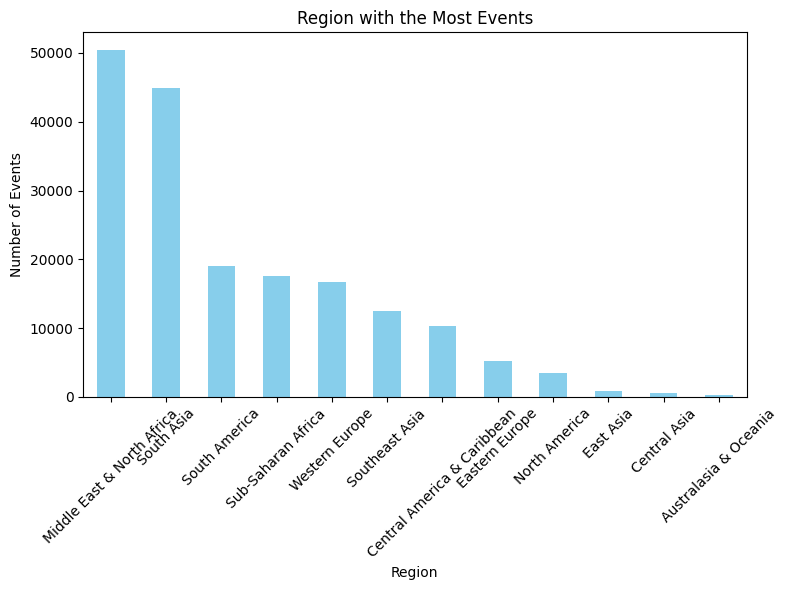

region_txt
Middle East & North Africa     50474
South Asia                     44974
South America                  18978
Sub-Saharan Africa             17550
Western Europe                 16639
Southeast Asia                 12485
Central America & Caribbean    10344
Eastern Europe                  5144
North America                   3456
East Asia                        802
Central Asia                     563
Australasia & Oceania            282
Name: count, dtype: int64

In [4]:
# Region-wise event counts
region_counts = Global['region_txt'].value_counts()

plt.figure(figsize=(8, 6))
region_counts.plot(kind='bar', color='skyblue')
plt.title("Region with the Most Events")
plt.xlabel('Region')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
region_counts

<h1>Insight 2: Most frequent event countries</h1>

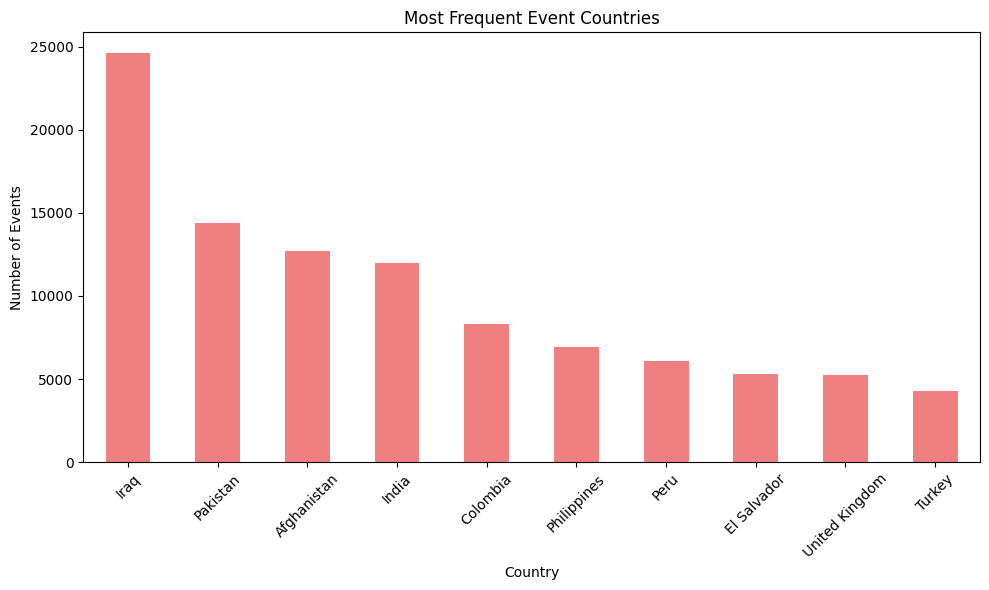

country_txt
Iraq              24636
Pakistan          14368
Afghanistan       12731
India             11960
Colombia           8306
Philippines        6908
Peru               6096
El Salvador        5320
United Kingdom     5235
Turkey             4292
Name: count, dtype: int64

In [5]:

country_counts = Global['country_txt'].value_counts().head(10)

plt.figure(figsize=(10, 6))
country_counts.plot(kind='bar', color='lightcoral')
plt.title("Most Frequent Event Countries")
plt.xlabel('Country')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
country_counts

<h1>Insight 3: Number of events per year by region</h1>

<Figure size 1200x600 with 0 Axes>

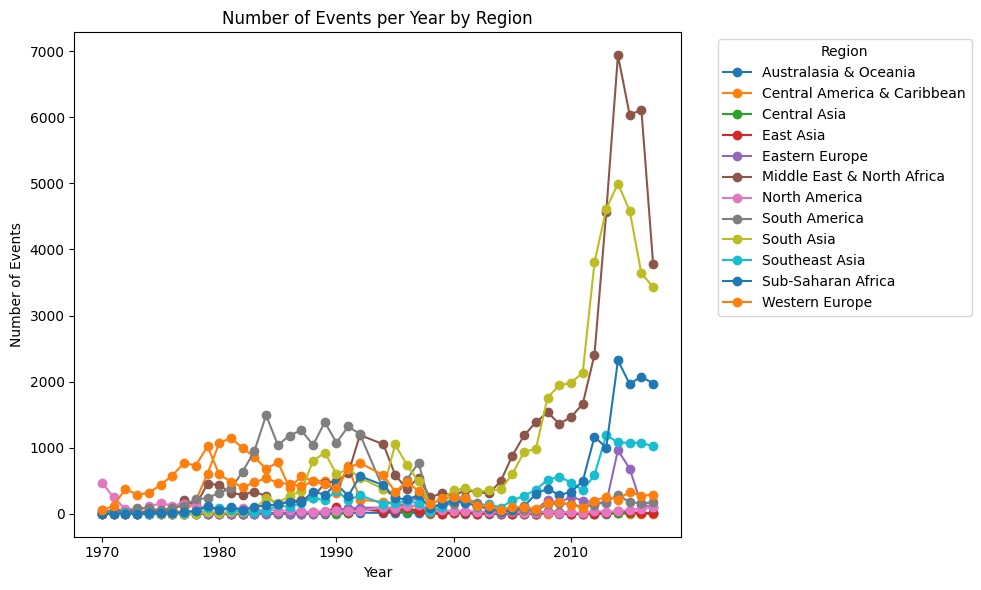

region_txt,Australasia & Oceania,Central America & Caribbean,Central Asia,East Asia,Eastern Europe,Middle East & North Africa,North America,South America,South Asia,Southeast Asia,Sub-Saharan Africa,Western Europe
iyear,,,,,,,,,,,,
1970,1.0,7.0,0.0,2.0,12.0,28.0,472.0,65.0,1.0,10.0,3.0,50.0
1971,1.0,5.0,0.0,1.0,5.0,55.0,247.0,24.0,0.0,6.0,2.0,125.0
1972,8.0,3.0,0.0,0.0,1.0,53.0,73.0,33.0,1.0,16.0,4.0,376.0
1973,1.0,6.0,0.0,2.0,1.0,19.0,64.0,83.0,1.0,2.0,4.0,290.0
1974,1.0,11.0,0.0,4.0,2.0,42.0,111.0,81.0,2.0,3.0,7.0,317.0
1975,0.0,9.0,0.0,12.0,0.0,44.0,159.0,55.0,4.0,7.0,12.0,438.0
1976,0.0,45.0,0.0,2.0,0.0,55.0,125.0,91.0,4.0,12.0,11.0,578.0
1977,0.0,24.0,0.0,4.0,2.0,211.0,149.0,119.0,2.0,8.0,29.0,771.0
1978,2.0,199.0,0.0,35.0,2.0,128.0,117.0,222.0,2.0,44.0,46.0,729.0


In [6]:

events_per_year = Global.groupby(['iyear', 'region_txt']).size().unstack().fillna(0)

plt.figure(figsize=(12, 6))
events_per_year.plot(kind='line', marker='o', linestyle='-', figsize=(10, 6))
plt.title('Number of Events per Year by Region')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
events_per_year

<h1>Insight 4: Most affected countries by region</h1>

['Central America & Caribbean' 'North America' 'Southeast Asia'
 'Western Europe' 'East Asia' 'South America' 'Eastern Europe'
 'Sub-Saharan Africa' 'Middle East & North Africa' 'Australasia & Oceania'
 'South Asia' 'Central Asia']


C:\Users\JUSTINEENRIQUEZ\AppData\Local\Temp\ipykernel_3828\4163264420.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

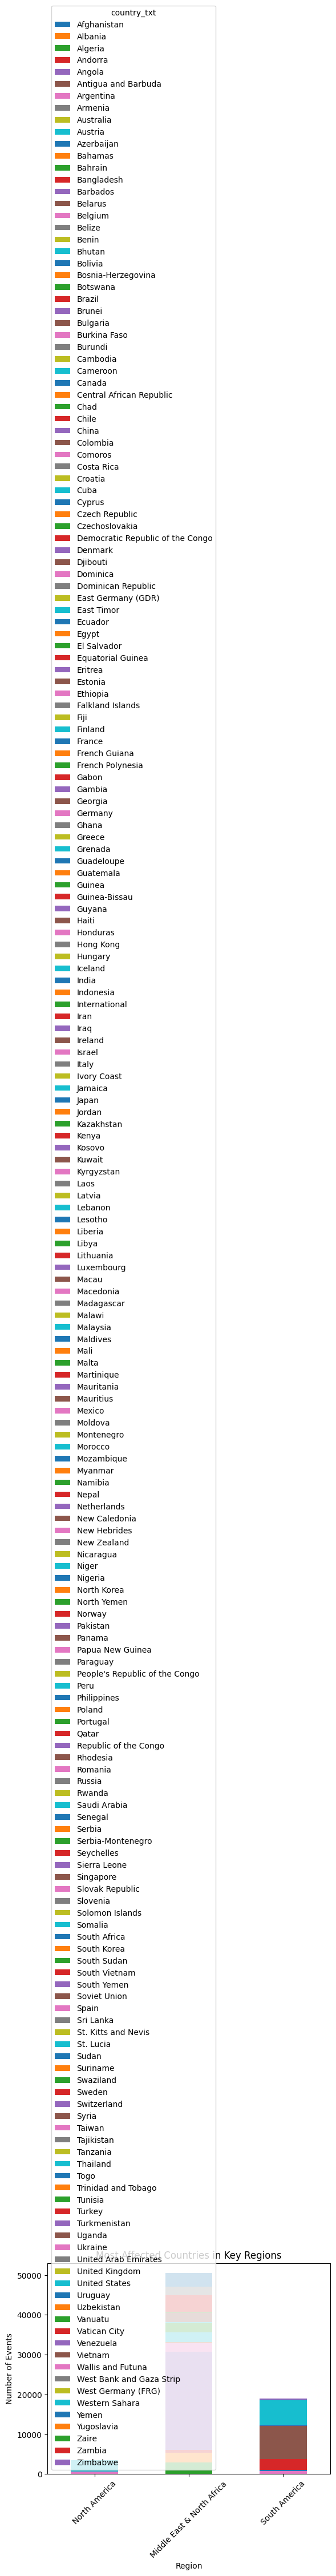

In [7]:
# Check the unique values in the 'region_txt' column to understand how regions are labeled
print(Global['region_txt'].unique())

# After checking, update top_regions based on the correct labels
top_regions = ['North America', 'Middle East & North Africa', 'South America']  # Example adjustment based on actual names

# Recompute the affected countries by region
affected_countries = Global.groupby(['region_txt', 'country_txt']).size().unstack().fillna(0)

# Now filter the affected countries by the correct regions
region_countries = affected_countries.loc[top_regions]

# Proceed with the visualization
plt.figure(figsize=(12, 6))
region_countries.plot(kind='bar', stacked=True)
plt.title("Most Affected Countries in Key Regions")
plt.xlabel('Region')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h1># Insight 5: Distribution of events by event resolution</h1>

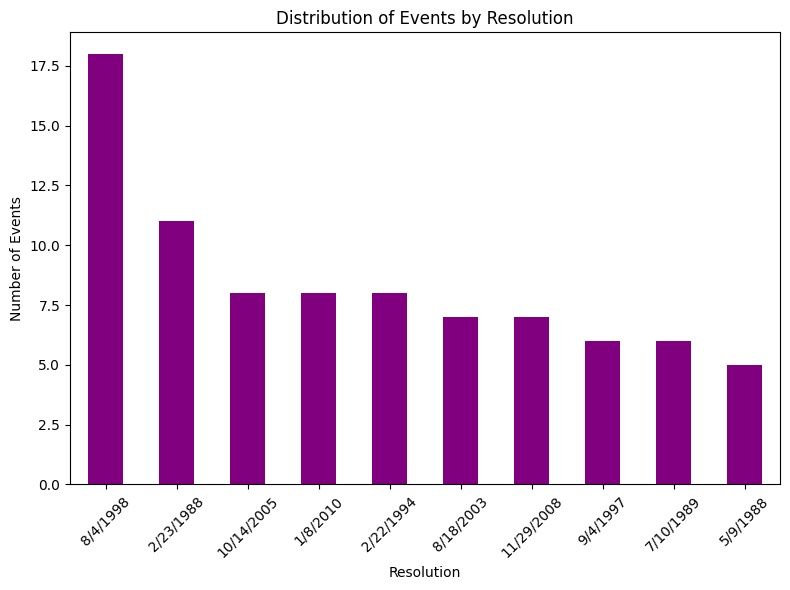

resolution
8/4/1998      18
2/23/1988     11
10/14/2005     8
1/8/2010       8
2/22/1994      8
8/18/2003      7
11/29/2008     7
9/4/1997       6
7/10/1989      6
5/9/1988       5
Name: count, dtype: int64

In [8]:
resolution_counts = Global['resolution'].value_counts().head(10)

plt.figure(figsize=(8, 6))
resolution_counts.plot(kind='bar', color='purple')
plt.title("Distribution of Events by Resolution")
plt.xlabel('Resolution')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
resolution_counts

<h1>Insight 6: Average number of events per region per year</h1>

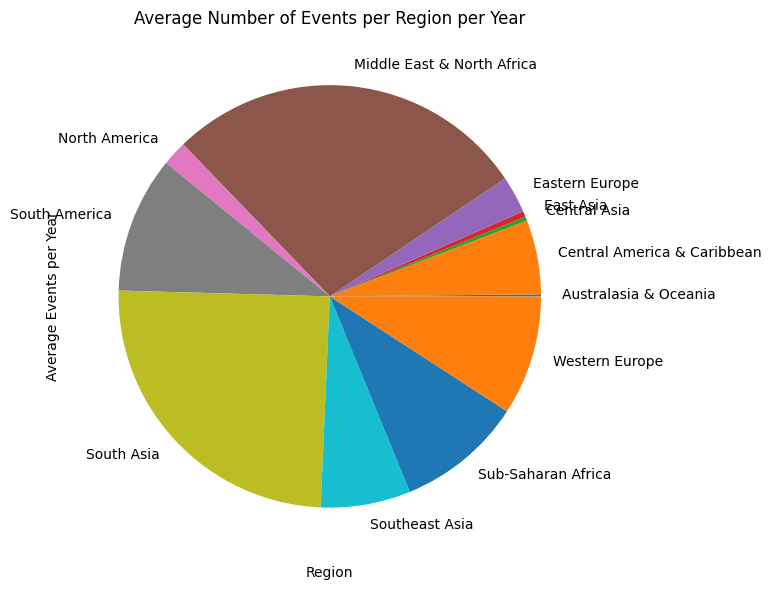

region_txt,Australasia & Oceania,Central America & Caribbean,Central Asia,East Asia,Eastern Europe,Middle East & North Africa,North America,South America,South Asia,Southeast Asia,Sub-Saharan Africa,Western Europe
iyear,,,,,,,,,,,,
1970,1.0,7.0,0.0,2.0,12.0,28.0,472.0,65.0,1.0,10.0,3.0,50.0
1971,1.0,5.0,0.0,1.0,5.0,55.0,247.0,24.0,0.0,6.0,2.0,125.0
1972,8.0,3.0,0.0,0.0,1.0,53.0,73.0,33.0,1.0,16.0,4.0,376.0
1973,1.0,6.0,0.0,2.0,1.0,19.0,64.0,83.0,1.0,2.0,4.0,290.0
1974,1.0,11.0,0.0,4.0,2.0,42.0,111.0,81.0,2.0,3.0,7.0,317.0
1975,0.0,9.0,0.0,12.0,0.0,44.0,159.0,55.0,4.0,7.0,12.0,438.0
1976,0.0,45.0,0.0,2.0,0.0,55.0,125.0,91.0,4.0,12.0,11.0,578.0
1977,0.0,24.0,0.0,4.0,2.0,211.0,149.0,119.0,2.0,8.0,29.0,771.0
1978,2.0,199.0,0.0,35.0,2.0,128.0,117.0,222.0,2.0,44.0,46.0,729.0


In [9]:
# Group by 'iyear' and 'region_txt' and calculate the size (event count)
events_per_year = Global.groupby(['iyear', 'region_txt']).size().unstack().fillna(0)

# Now, calculate the average events per region across the years
avg_events_per_region = events_per_year.mean(axis=0)

# Plot the average number of events per region per year
plt.figure(figsize=(10, 6))
avg_events_per_region.plot(kind='pie', color='green')
plt.title("Average Number of Events per Region per Year")
plt.xlabel('Region')
plt.ylabel('Average Events per Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

events_per_year

<h1>Insight 7: Region with the highest number of event types</h1>

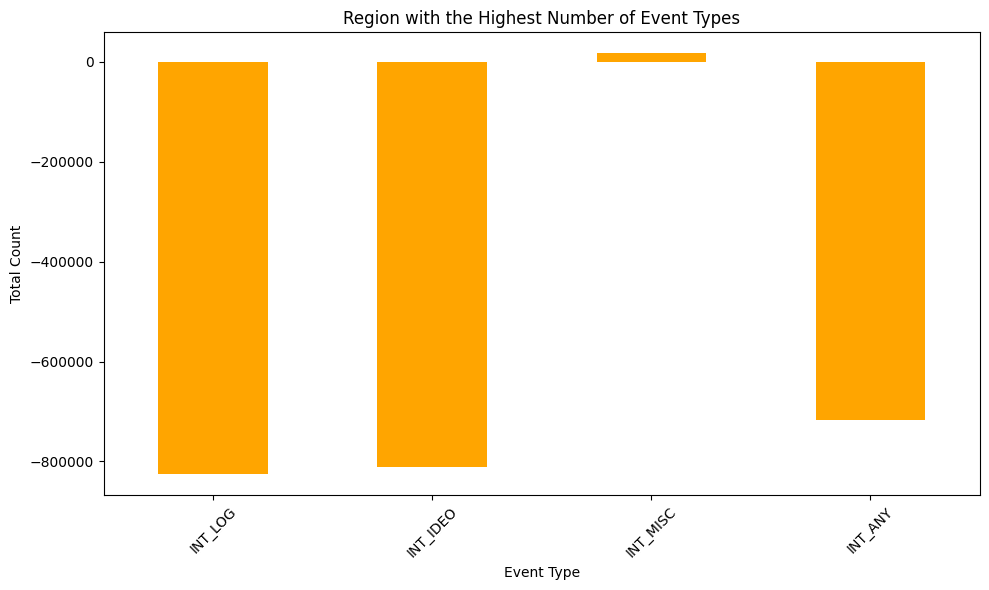

INT_LOG    -825555
INT_IDEO   -811141
INT_MISC     16354
INT_ANY    -716944
dtype: int64

In [10]:
event_types = ['INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']
event_type_counts = Global[event_types].sum()

plt.figure(figsize=(10, 6))
event_type_counts.plot(kind='bar', color='orange')
plt.title("Region with the Highest Number of Event Types")
plt.xlabel('Event Type')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
event_type_counts 

<h1>Insight 8: Monthly distribution of events by region</h1>

<Figure size 1200x600 with 0 Axes>

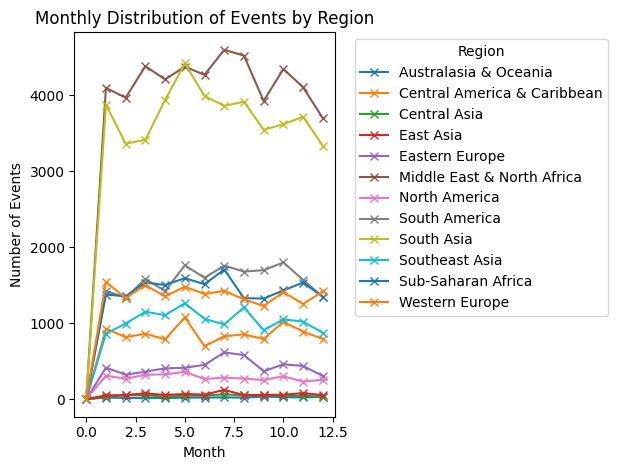

region_txt,Australasia & Oceania,Central America & Caribbean,Central Asia,East Asia,Eastern Europe,Middle East & North Africa,North America,South America,South Asia,Southeast Asia,Sub-Saharan Africa,Western Europe
imonth,,,,,,,,,,,,
0,0.0,1.0,0.0,4.0,0.0,2.0,2.0,3.0,2.0,2.0,0.0,4.0
1,23.0,927.0,32.0,50.0,416.0,4095.0,310.0,1425.0,3874.0,864.0,1377.0,1543.0
2,17.0,817.0,52.0,56.0,323.0,3966.0,269.0,1336.0,3361.0,996.0,1355.0,1331.0
3,18.0,861.0,55.0,77.0,363.0,4380.0,323.0,1582.0,3413.0,1151.0,1535.0,1499.0
4,15.0,788.0,32.0,57.0,406.0,4207.0,327.0,1423.0,3936.0,1105.0,1503.0,1353.0
5,21.0,1077.0,48.0,69.0,414.0,4374.0,360.0,1761.0,4416.0,1263.0,1592.0,1480.0
6,23.0,698.0,49.0,61.0,453.0,4267.0,266.0,1598.0,3988.0,1058.0,1513.0,1385.0
7,24.0,828.0,64.0,123.0,616.0,4596.0,285.0,1758.0,3859.0,984.0,1706.0,1425.0
8,22.0,854.0,52.0,54.0,581.0,4520.0,272.0,1679.0,3914.0,1208.0,1330.0,1314.0


In [11]:
monthly_distribution = Global.groupby(['imonth', 'region_txt']).size().unstack().fillna(0)

plt.figure(figsize=(12, 6))
monthly_distribution.plot(kind='line', marker='x')
plt.title('Monthly Distribution of Events by Region')
plt.xlabel('Month')
plt.ylabel('Number of Events')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
monthly_distribution

<h1> Insight 9: Impact of events (INT_MISC, INT_ANY)</h1>


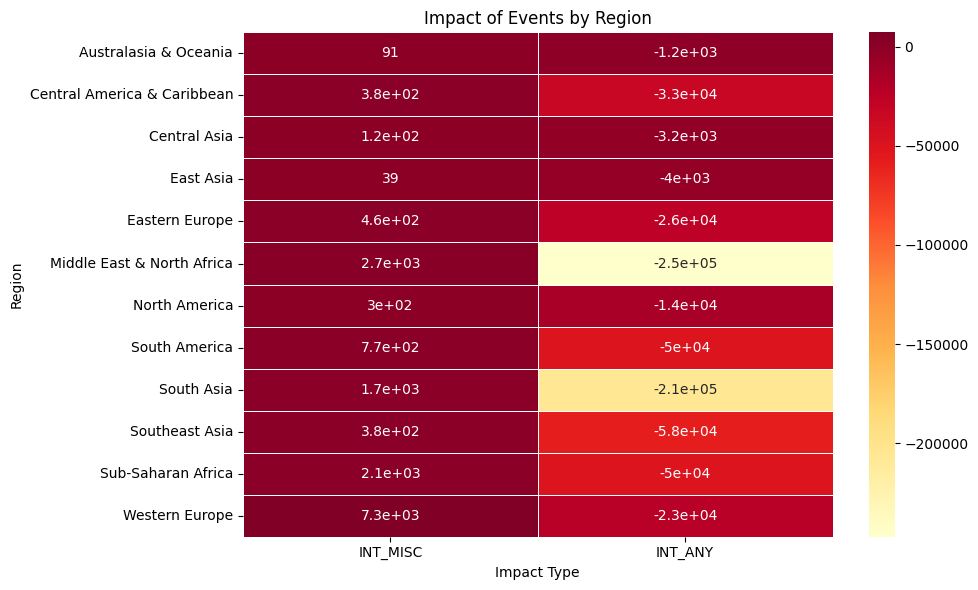

,INT_MISC,INT_ANY
region_txt,,
Australasia & Oceania,91,-1243
Central America & Caribbean,377,-33318
Central Asia,115,-3172
East Asia,39,-3965
Eastern Europe,457,-25879
Middle East & North Africa,2749,-247223
North America,303,-14198
South America,774,-50202
South Asia,1745,-206434


In [12]:
# Assuming 'Global' is your dataframe containing the event data
impact_by_region = Global.groupby('region_txt')[['INT_MISC', 'INT_ANY']].sum()

# Plotting the heatmap for the impact of events by region
plt.figure(figsize=(10, 6))

# Use seaborn to create a heatmap
sns.heatmap(impact_by_region, annot=True, cmap='YlOrRd', cbar=True, linewidths=0.5)

# Set plot title and labels
plt.title("Impact of Events by Region")
plt.xlabel("Impact Type")
plt.ylabel("Region")

# Show the plot
plt.tight_layout()
plt.show()
impact_by_region

<h1>Insight 10: Countries with the highest regional conflict activity</h1>

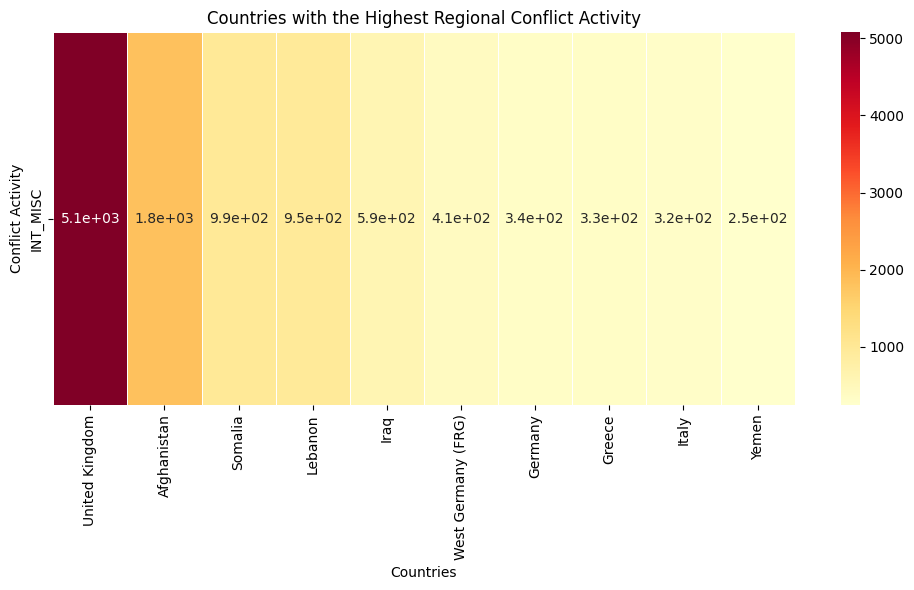

country_txt
United Kingdom        5076
Afghanistan           1818
Somalia                992
Lebanon                953
Iraq                   593
West Germany (FRG)     413
Germany                340
Greece                 327
Italy                  319
Yemen                  250
Name: INT_MISC, dtype: int64

In [13]:

conflict_activity = Global.groupby('country_txt')['INT_MISC'].sum().sort_values(ascending=False).head(10)

# Convert the series into a DataFrame for heatmap visualization
conflict_activity_df = conflict_activity.reset_index()
conflict_activity_df = conflict_activity_df.set_index('country_txt')

# Reshape the data into a format suitable for the heatmap (just one column of activity values)
conflict_activity_matrix = conflict_activity_df.T  # Transpose to make it 1x10 matrix

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(conflict_activity_matrix, annot=True, cmap='YlOrRd', cbar=True, linewidths=0.5)

# Set plot title and labels
plt.title("Countries with the Highest Regional Conflict Activity")
plt.xlabel("Countries")
plt.ylabel("Conflict Activity")

# Show the plot
plt.tight_layout()
plt.show()
conflict_activity